In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import re
from collections import Counter

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

from wordcloud import WordCloud

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
train = pd.read_csv("train.txt", sep=";", names=["text", "emotion"])
val = pd.read_csv("val.txt", sep=";", names=["text", "emotion"])
test = pd.read_csv("test.txt", sep=";", names=["text", "emotion"])

print(train.head())
print(train.info())
print(train['emotion'].value_counts())
print(train.isna().sum())


                                                text  emotion
0                            i didnt feel humiliated  sadness
1  i can go from feeling so hopeless to so damned...  sadness
2   im grabbing a minute to post i feel greedy wrong    anger
3  i am ever feeling nostalgic about the fireplac...     love
4                               i am feeling grouchy    anger
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     16000 non-null  object
 1   emotion  16000 non-null  object
dtypes: object(2)
memory usage: 250.1+ KB
None
emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64
text       0
emotion    0
dtype: int64


In [3]:
train = train.dropna().drop_duplicates()

train['text'] = (
    train['text']
    .str.lower()
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

In [4]:
train['text_length'] = train['text'].apply(len)
train['word_count'] = train['text'].str.split().apply(len)
train['unique_word_count'] = train['text'].str.split().apply(lambda x: len(set(x)))
train['punctuation_count'] = train['text'].apply(lambda s: len(re.findall(r'[^\w\s]', s)))

train['avg_word_length'] = train.apply(
    lambda r: np.mean([len(w) for w in r['text'].split()]) if r['word_count']>0 else 0,
    axis=1
)

/tmp/ipython-input-2608884965.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=order)


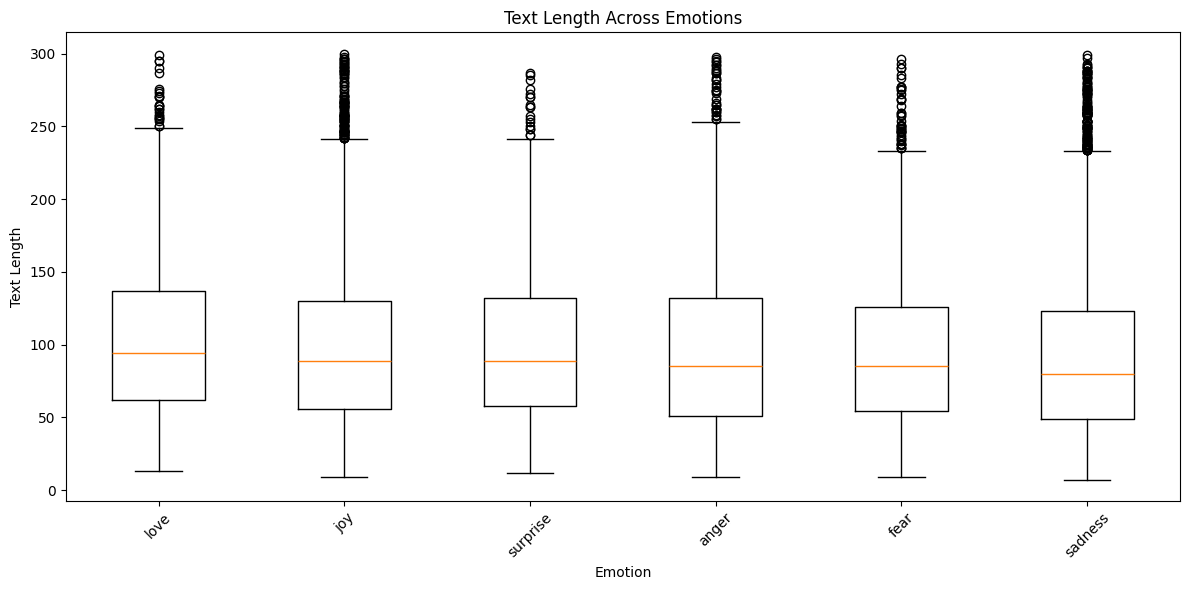

In [24]:
# === 5.3 Boxplot: Text Length by Emotion ===
plt.figure(figsize=(12,6))
order = train.groupby('emotion')['text_length'].median().sort_values(ascending=False).index
data_to_plot = [train.loc[train['emotion']==e, 'text_length'] for e in order]
plt.boxplot(data_to_plot, labels=order)
plt.title('Text Length Across Emotions')
plt.xlabel('Emotion')
plt.ylabel('Text Length')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Text Length Across Emotions.png", dpi=300, bbox_inches="tight")
plt.show()


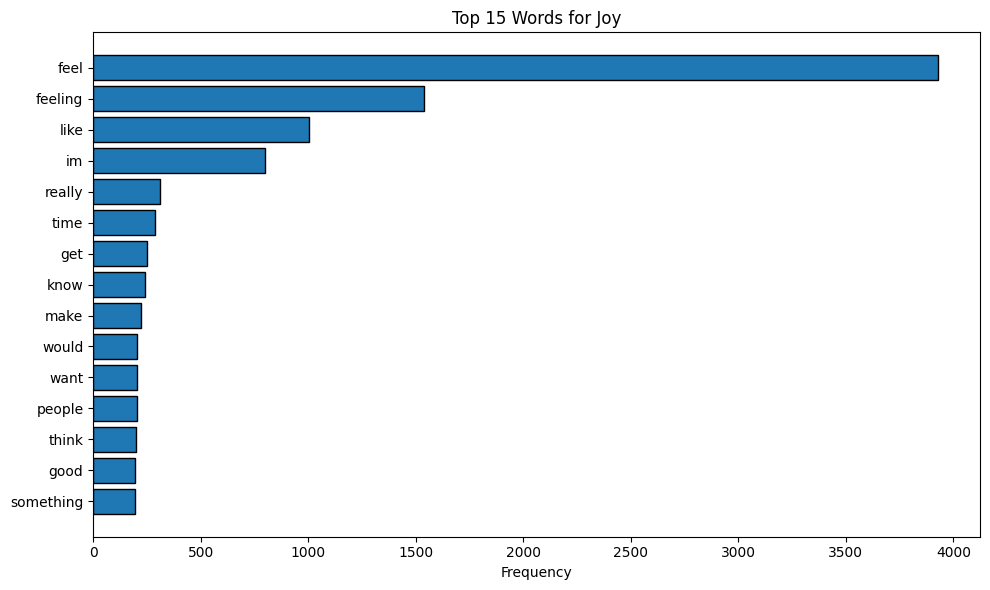

In [22]:

# === 5.6 Word Frequency (Joy) ===
stop = set(stopwords.words('english'))

def top_n_words(df, emotion_label, n=15):
    text = " ".join(df[df['emotion']==emotion_label]['text'])
    words = [w for w in re.findall(r'\w+', text.lower()) if w not in stop]
    return Counter(words).most_common(n)

top_joy = top_n_words(train, 'joy', 15)
words, counts = zip(*top_joy)

plt.figure(figsize=(10,6))
plt.barh(words[::-1], counts[::-1], edgecolor='black')
plt.title('Top 15 Words for Joy')
plt.xlabel('Frequency')
plt.tight_layout()
plt.savefig("Top 15 Words for Joy.png", dpi=300, bbox_inches="tight")
plt.show()


In [7]:
train.to_csv("emotion_dataset_cleaned.csv", index=False)


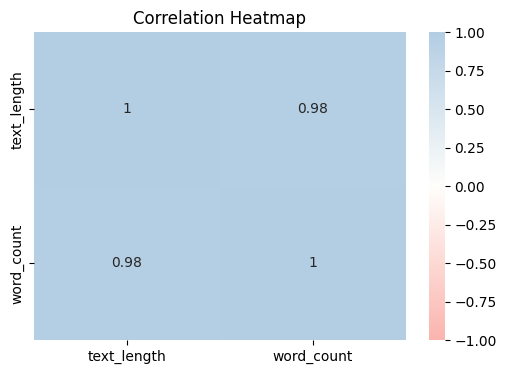

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Load the cleaned dataset
df = pd.read_csv("emotion_dataset_cleaned.csv")

# Select numeric columns
numeric_cols = ["text_length", "word_count"]
corr = df[numeric_cols].corr()

# Create pastel diverging colormap
pastel_cmap = LinearSegmentedColormap.from_list("pastel_diverging", ["#fbb4ae", "#fefefb", "#b3cde3"])

# Plot the heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap=pastel_cmap, vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.savefig("Correlation Heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


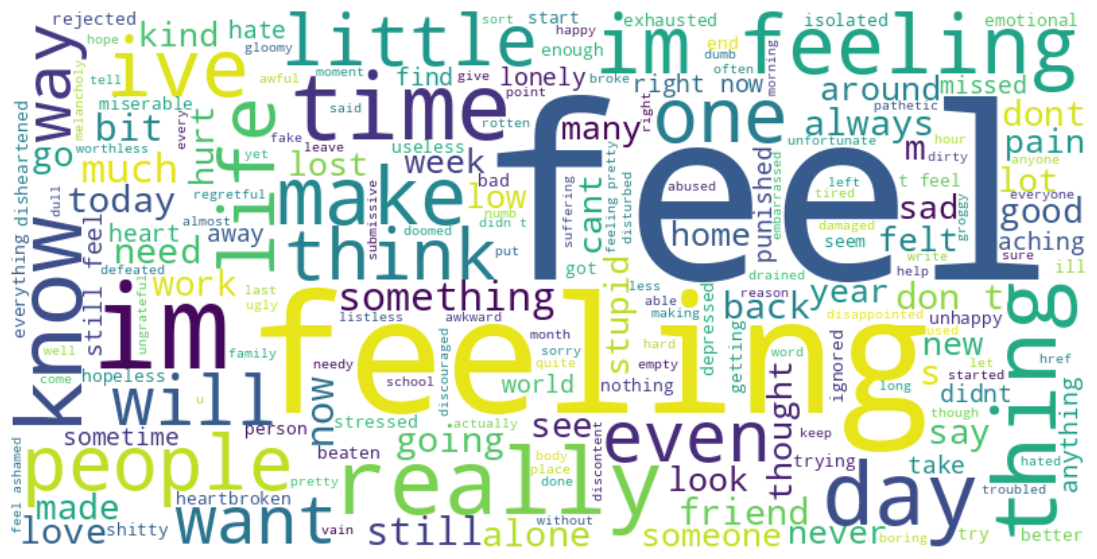

In [9]:
text = " ".join(train.loc[train['emotion']=="sadness", 'text'])
wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(14,7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')

# SAVE IT AS A FILE
plt.savefig("wordcloud_sadness.png", dpi=300, bbox_inches='tight')
plt.show()


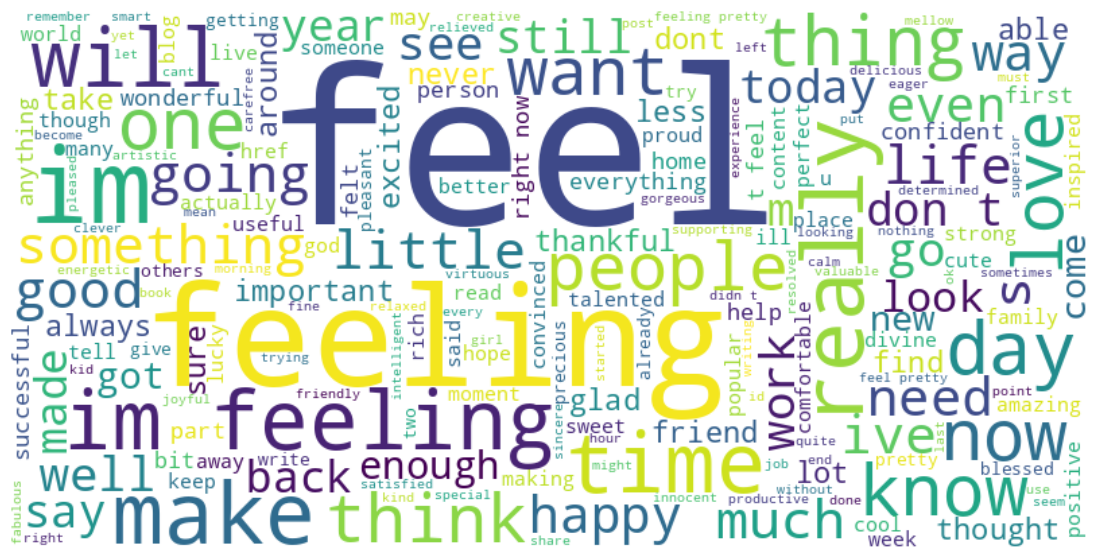

In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Select only JOY texts
text_joy = " ".join(train[train['emotion'] == "joy"]['text'])

# Generate word cloud
wc_joy = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text_joy)

# Display and save
plt.figure(figsize=(14, 7))
plt.imshow(wc_joy, interpolation='bilinear')
plt.axis('off')

# SAVE AS PNG FILE
plt.savefig("wordcloud_joy.png", dpi=300, bbox_inches='tight')
plt.show()


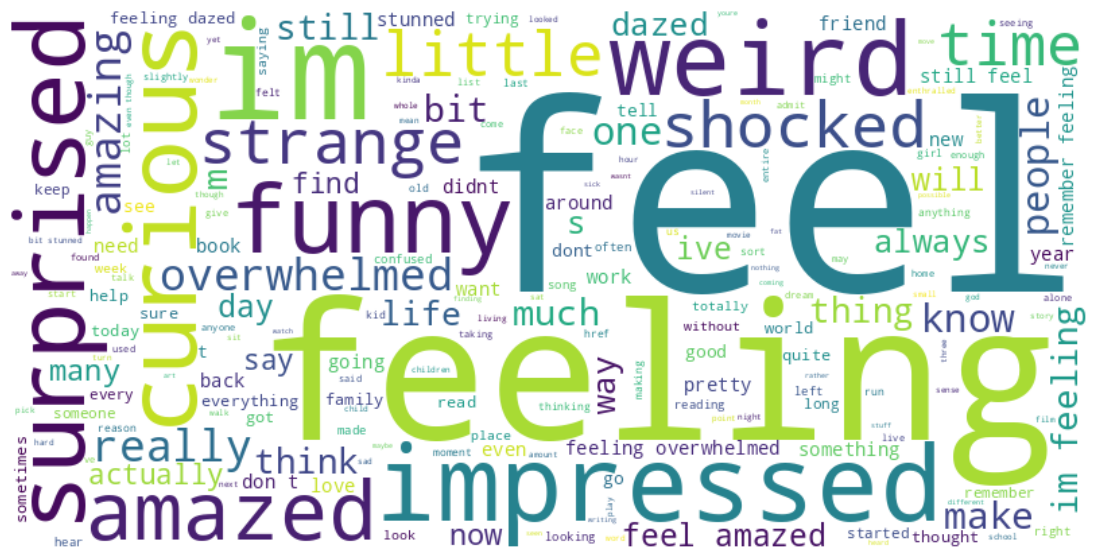

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Select only SURPRISE texts
text_surprise = " ".join(train[train['emotion'] == "surprise"]['text'])

# Generate word cloud
wc_surprise = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text_surprise)

# Display and save
plt.figure(figsize=(14, 7))
plt.imshow(wc_surprise, interpolation='bilinear')
plt.axis('off')

# SAVE AS PNG FILE
plt.savefig("wordcloud_surprise.png", dpi=300, bbox_inches='tight')
plt.show()
